# Step 1: Log in to Space-Track

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from spacetrack import SpaceTrackClient
import spacetrack.operators as op

from io import StringIO
import pickle

import time
import datetime
from datetime import datetime, timedelta


# Load your own SpaceTrack credentials
with open('spacetrackcreds.txt', 'r') as f:
    content = f.read()
st_un = content.split(",")[0].strip()
st_pw = content.split(",")[1].strip()

st = SpaceTrackClient(identity=f'{st_un}', password=f'{st_pw}')

# Step 2: Acquire satellite characteristics data from Space-Track & NASA

In [2]:
rus_sats = st.satcat(country="CIS", format="csv")
print(rus_sats)

INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,COMMENT,COMMENTCODE,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
"1957-001A","1","ROCKET BODY","SL-1 R/B","CIS","1957-10-04","TTMTR","1957-12-01","96.19","65.10","938","214","","4","0","LARGE","1","1957","1","A","Y","SL-1 R/B","1957-001A","1"
"1958-004A","7","ROCKET BODY","SL-1 R/B","CIS","1958-05-15","TTMTR","1958-12-03","102.74","65.14","1571","206","","","0","","1","1958","4","A","Y","SL-1 R/B","1958-004A","7"
"1958-004B","8","PAYLOAD","SPUTNIK 3","CIS","1958-05-15","TTMTR","1960-04-06","88.43","65.06","255","139","","","0","LARGE","1","1958","4","B","Y","SPUTNIK 3","1958-004B","8"
"1959-008A","21","PAYLOAD","LUNA 3","CIS","1959-10-04","TTMTR","1960-04-20","21563.22","55.00","499998","500","","","0","","1","1959","8","A","Y","LUNA 3","1959-008A","21"
"1960-005A","34","PAYLOAD","SPUTNIK 4","CIS","1960-05-15","TTMTR","1962-09-05

In [ ]:
split = rus_sats.split('\n')
#print(len(split))
# number of lines in the satcat query for russian objects

# Join into one CSV string
csv_text = "\n".join(split)

# Read into DataFrame
satcat_df = pd.read_csv(StringIO(csv_text))
#print(satcat_df.head())
print(len(satcat_df))

25144


In [4]:
satcat_df = satcat_df[satcat_df['OBJECT_TYPE'] != 'DEBRIS']
print(satcat_df[satcat_df['NORAD_CAT_ID'] == 44626])  # prove a particular satellite is still orbiting by checking LAUNCH and DECAY


satcat_df = satcat_df[["NORAD_CAT_ID", "COUNTRY", "OBJECT_TYPE", "LAUNCH", "DECAY", "INTLDES"]]
print("Total # of non-debris Russian satellites: ", satcat_df.shape[0])
# looks good, 5 cols, 7762 rows, all non-debris russian objects

satcat_df['LAUNCH'] = pd.to_datetime(satcat_df['LAUNCH'], errors='coerce')
satcat_df['DECAY'] = pd.to_datetime(satcat_df['DECAY'], errors='coerce')


satcat_df = satcat_df[satcat_df["LAUNCH"] < "2022-03-24"]
#print(sorted(satcat_df["DECAY"][satcat_df["DECAY"] > "2022-01-01"]))  # shows that some sats decayed in early 2022

satcat_df = satcat_df[(satcat_df["DECAY"] > "2022-03-24") | (pd.isna(satcat_df["DECAY"]))]
#print(sorted(satcat_df["DECAY"].unique()))

print("# of satellites used in analysis: ", satcat_df.shape[0])
# looks good, 5 cols, 2636 rows, all non-debris STILL ORBITING russian objects
# little bit less than the paper but some probably de-orbited

         INTLDES  NORAD_CAT_ID  OBJECT_TYPE       SATNAME COUNTRY      LAUNCH  \
24893  2019-067C         44626  ROCKET BODY  BREEZE-M R/B     CIS  2019-10-09   

        SITE DECAY   PERIOD  INCLINATION  ...  RCSVALUE  RCS_SIZE  FILE  \
24893  TTMTR   NaN  1534.35         21.9  ...         0     LARGE  9314   

       LAUNCH_YEAR  LAUNCH_NUM LAUNCH_PIECE  CURRENT   OBJECT_NAME  OBJECT_ID  \
24893         2019          67            C        Y  BREEZE-M R/B  2019-067C   

      OBJECT_NUMBER  
24893         44626  

[1 rows x 24 columns]
Total # of non-debris Russian satellites:  7762
# of satellites used in analysis:  2606


In [ ]:
# "Discipline" characterizations / mission classifications from NASA
file_path_nasa = 'Kurtenbach_files/NASA_SSCDA_satdiscipline.xlsx'
nasa_df = pd.read_excel(file_path_nasa)

# Step 3: Query Space-Track for all non-debris Russian TLEs (satellite telemetry data) which were orbiting in defined pre-war period

In [ ]:
norads = list(satcat_df['NORAD_CAT_ID'].to_numpy())[0:651]
# actual desired IDs, first batch

first_lst = []
chunk_size = 10

for i in range(0, len(norads), chunk_size):
    subset = norads[i:i + chunk_size]
    print(f"Fetching NORAD IDs {i}–{i + chunk_size} / {len(norads)}")

    try:
        query = st.tle(
            norad_cat_id=subset,
            epoch=op.inclusive_range('2016-08-24', '2022-03-24'),
            orderby='epoch desc',
            format='tle'
        )
        tles = query.split('\n')
        # Each TLE entry is two lines — group them into pairs
        first_lst.extend([tles[j:j + 2] for j in range(0, len(tles), 2)])
        print(f"Retrieved {len(tles)//2} TLEs for this batch.")

    except Exception as e:
        print(f"Skipped batch {i}–{i + chunk_size}: {e}")

    # Avoid hitting SpaceTrack rate limits
    time.sleep(2)

print(f"\nDone! Total TLE sets collected: {len(first_lst)}")


Fetching NORAD IDs 0–10 / 651


C:\Users\kylyn\AppData\Local\Temp\ipykernel_23028\4087076513.py:12: DeprecationWarning: The tle request class is deprecated and scheduled to be removed. Visit https://www.space-track.org for more information.
  query = st.tle(


Retrieved 1905 TLEs for this batch.
Fetching NORAD IDs 10–20 / 651
Retrieved 5219 TLEs for this batch.
Fetching NORAD IDs 20–30 / 651
Retrieved 24354 TLEs for this batch.
Fetching NORAD IDs 30–40 / 651
Skipped batch 30–40: The read operation timed out
Fetching NORAD IDs 40–50 / 651
Retrieved 34606 TLEs for this batch.
Fetching NORAD IDs 50–60 / 651
Skipped batch 50–60: The read operation timed out
Fetching NORAD IDs 60–70 / 651
Skipped batch 60–70: The read operation timed out
Fetching NORAD IDs 70–80 / 651
Retrieved 38198 TLEs for this batch.
Fetching NORAD IDs 80–90 / 651
Retrieved 35377 TLEs for this batch.
Fetching NORAD IDs 90–100 / 651
Retrieved 33847 TLEs for this batch.
Fetching NORAD IDs 100–110 / 651
Retrieved 34661 TLEs for this batch.
Fetching NORAD IDs 110–120 / 651
Retrieved 35199 TLEs for this batch.
Fetching NORAD IDs 120–130 / 651
Retrieved 35739 TLEs for this batch.
Fetching NORAD IDs 130–140 / 651
Retrieved 37487 TLEs for this batch.
Fetching NORAD IDs 140–150 / 651


In [ ]:
from parse_tle import parse_tle_to_df
# This helper py file parses the tle outputs from space-track into separate columns for each orbital element,
# as well as additional information about the track

df = parse_tle_to_df(first_lst)
df.to_parquet("tles/spacetrack_tle_df_1.parquet", engine='pyarrow', compression = 'gzip', index =True)
# https://ensatellite.com/tle-epoch-to-date/ --> can confirm that the dates are correct

In [ ]:
norads = list(satcat_df['NORAD_CAT_ID'].to_numpy())[651:1303]
# actual desired IDs, second batch

second_lst = []
chunk_size = 10

for i in range(0, len(norads), chunk_size):
    subset = norads[i:i + chunk_size]
    print(f"Fetching NORAD IDs {i}–{i + chunk_size} / {len(norads)}")

    try:
        query = st.tle(
            norad_cat_id=subset,
            epoch=op.inclusive_range('2016-08-24', '2022-03-24'),
            orderby='epoch desc',
            format='tle'
        )
        tles = query.split('\n')
        # Each TLE entry is two lines — group them into pairs
        second_lst.extend([tles[j:j + 2] for j in range(0, len(tles), 2)])
        print(f"Retrieved {len(tles)//2} TLEs for this batch.")

    except Exception as e:
        print(f"Skipped batch {i}–{i + chunk_size}: {e}")

    # Avoid hitting SpaceTrack rate limits
    time.sleep(2)

print(f"\nDone! Total TLE sets collected: {len(second_lst)}")


In [ ]:
df = parse_tle_to_df(second_lst)
df.to_parquet("tles/spacetrack_tle_df_2.parquet", engine='pyarrow', compression = 'gzip', index =True)
# https://ensatellite.com/tle-epoch-to-date/ --> can confirm that the dates are correct

In [ ]:
norads = list(satcat_df['NORAD_CAT_ID'].to_numpy())[1303:1854]
# actual desired IDs, third batch

third_lst = []
chunk_size = 10

for i in range(0, len(norads), chunk_size):
    subset = norads[i:i + chunk_size]
    print(f"Fetching NORAD IDs {i}–{i + chunk_size} / {len(norads)}")

    try:
        query = st.tle(
            norad_cat_id=subset,
            epoch=op.inclusive_range('2016-08-24', '2022-03-24'),
            orderby='epoch desc',
            format='tle'
        )
        tles = query.split('\n')
        # Each TLE entry is two lines — group them into pairs
        third_lst.extend([tles[j:j + 2] for j in range(0, len(tles), 2)])
        print(f"Retrieved {len(tles)//2} TLEs for this batch.")

    except Exception as e:
        print(f"Skipped batch {i}–{i + chunk_size}: {e}")

    # Avoid hitting SpaceTrack rate limits
    time.sleep(2)

print(f"\nDone! Total TLE sets collected: {len(third_lst)}")


In [ ]:
df2 = parse_tle_to_df(third_lst)
df2.to_parquet("tles/spacetrack_tle_df_3.parquet", engine='pyarrow', compression = 'gzip', index =True)
# https://ensatellite.com/tle-epoch-to-date/ --> can confirm that the dates are correct

NameError: name 'full_lst' is not defined

In [ ]:
norads = list(satcat_df['NORAD_CAT_ID'].to_numpy())[1854:2606]
# actual desired IDs, fourth batch

fourth_lst = []
chunk_size = 10

for i in range(0, len(norads), chunk_size):
    subset = norads[i:i + chunk_size]
    print(f"Fetching NORAD IDs {i}–{i + chunk_size} / {len(norads)}")

    try:
        query = st.tle(
            norad_cat_id=subset,
            epoch=op.inclusive_range('2016-08-24', '2022-03-24'),
            orderby='epoch desc',
            format='tle'
        )
        tles = query.split('\n')
        # Each TLE entry is two lines — group them into pairs
        fourth_lst.extend([tles[j:j + 2] for j in range(0, len(tles), 2)])
        print(f"Retrieved {len(tles)//2} TLEs for this batch.")

    except Exception as e:
        print(f"Skipped batch {i}–{i + chunk_size}: {e}")

    # Avoid hitting SpaceTrack rate limits
    time.sleep(2)

print(f"\nDone! Total TLE sets collected: {len(fourth_lst)}")


In [ ]:
df = parse_tle_to_df(fourth_lst)
df.to_parquet("tles/spacetrack_tle_df_4.parquet", engine='pyarrow', compression = 'gzip', index =True)
# https://ensatellite.com/tle-epoch-to-date/ --> can confirm that the dates are correct

In [ ]:
import pyarrow.parquet as pq
import os

# Combine all 4 datasets into one parquet file for analysis
def combine_parquet_files(input_dir):
    files = []
    for file_name in os.listdir(input_dir):
        files.append(os.path.join(input_dir, file_name))

    # Open writer lazily
    writer = None

    for f in files:
        reader = pq.ParquetFile(f)
        for batch in reader.iter_batches():  # Stream each file in record batches
            if writer is None:
                writer = pq.ParquetWriter("spacetrack_tle_df_merged.parquet", batch.schema)
            writer.write_batch(batch)

    # Close writer at the end
    if writer:
       writer.close()

combine_parquet_files("tles/")
# see README.md for how to acquire these tles/ without downloading from space-track yourself

# Step 3: Merge TLE data with satellite characterizations and NASA classification information

In [ ]:
tle_df = pd.read_parquet("spacetrack_tle_df_merged.parquet")
tle_df['datetime'] = (pd.to_datetime((tle_df['epoch_year']+2000).astype(int).astype(str) + '-01-01')
                      + pd.to_timedelta(tle_df['epoch_day'] - 1, unit='D'))

# Ensure relevant ID fields are of the same type for merging
satcat_df['NORAD_CAT_ID'] = satcat_df['NORAD_CAT_ID'].astype(int)
tle_df['catalog_number'] = tle_df['catalog_number'].astype(int)
#ucs_df['NORAD Number'] = ucs_df['NORAD Number'].astype(int)

# Merge combined_df with additional data from NASA categorizations
# We only bring in relevant columns to avoid redundant data
merged_df = pd.merge(tle_df, satcat_df[['NORAD_CAT_ID', 'COUNTRY', 'OBJECT_TYPE', 'INTLDES']], 
                     how='left', left_on='catalog_number', right_on='NORAD_CAT_ID')
merged_df = pd.merge(merged_df, 
                     nasa_df[['NSSDCA ID', 
                             'Discipline']],
                     how='left', left_on='INTLDES', right_on='NSSDCA ID')

# Show the types of objects included in the dataset
print(merged_df['OBJECT_TYPE'].unique())



## UNCOMMENT to produce OWN filtered_df:
########################################################################
# Remove duplicates to get unique satellite entries based on the criteria
#filtered_df = merged_df.drop_duplicates()

#print(len(filtered_df['NORAD_CAT_ID'].unique()))

#filtered_df.columns
########################################################################

# Save filtered_df as a csv for use in future modeling
# filtered_df.to_csv("filtered_df.csv", index=False)

['PAYLOAD' 'ROCKET BODY' 'UNKNOWN']
2511


Index(['line1', 'line2', 'catalog_number', 'classification', 'launch_year',
       'launch_number', 'launch_piece', 'epoch_year', 'epoch_day',
       'mean_motion_dot', 'mean_motion_ddot', 'bstar', 'ephemeris_type',
       'element_number', 'satellite_number', 'inclination', 'ra_of_asc_node',
       'eccentricity', 'arg_of_perigee', 'mean_anomaly', 'mean_motion',
       'rev_at_epoch', 'datetime', 'NORAD_CAT_ID', 'COUNTRY', 'OBJECT_TYPE',
       'INTLDES', 'NSSDCA ID', 'Discipline'],
      dtype='object')

# Step 4: Define outliers using IQR detection algorithm

In [24]:
# Load previously created filtered_csv
filtered_df = pd.read_csv("filtered_df.csv", index_col=0)

C:\Users\kylyn\AppData\Local\Temp\ipykernel_27064\3127416472.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv("filtered_df.csv", index_col=0)


In [26]:
features = ['inclination',
            'mean_motion',
            'eccentricity', 
            'ra_of_asc_node',
            'arg_of_perigee',
            'mean_anomaly']

filtered_df = filtered_df.copy()
filtered_df['outlier_persat'] = False
# initializes outlier column, will be set to true per row if the row has anomalous features
# (i.e. if any of the satellite orbital elements are outside of 1.5x +/- that element's IQR,
#  for that particular satellite)

for feature in features:
    # Compute per-satellite IQR
    Q1 = filtered_df.groupby('NORAD_CAT_ID')[feature].transform(lambda x: x.quantile(0.25))
    Q3 = filtered_df.groupby('NORAD_CAT_ID')[feature].transform(lambda x: x.quantile(0.75))
    IQR = Q3 - Q1
    
    # Flag outliers per observation
    filtered_df[f'outlier_{feature}'] = ((filtered_df[feature] < Q1 - 1.5*IQR) |
                                         (filtered_df[feature] > Q3 + 1.5*IQR)).astype(int)
    
    # Combine across features
    filtered_df['outlier_persat'] |= filtered_df[f'outlier_{feature}']
    print(f"Calculated outliers for {feature}")

print("Per-observation outlier flags computed for all satellites.")

Calculated outliers for inclination
Calculated outliers for mean_motion
Calculated outliers for eccentricity
Calculated outliers for ra_of_asc_node
Calculated outliers for arg_of_perigee
Calculated outliers for mean_anomaly
Per-observation outlier flags computed for all satellites.


# Step 5: Fit RandomForestClassifier to the buildup period data with outliers as baseline

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder

import joblib


## Need to change categorical variables to factors:

# Replace missing values with a placeholder
filtered_df['Discipline'] = filtered_df['Discipline'].fillna('Unknown')

# Create factors/assign a value to each unique entry for Discipline
encoder = OrdinalEncoder()
filtered_df['mission_type_encoded'] = encoder.fit_transform(filtered_df[['Discipline']])

type_factors = {'PAYLOAD': 0, 'ROCKET BODY': 1, 'UNKNOWN': 2}
filtered_df['object_type_encoded'] = filtered_df['OBJECT_TYPE'].map(type_factors)


# Separating early data to train on:
train_df = filtered_df[(filtered_df['datetime'] >= "2018-01-01") & (filtered_df['datetime'] < "2021-08-24")]

# Select which features to include when training the model -
# I used the 6 orbital elements, object type, and mission type
features_to_use = ['inclination', 'mean_motion', 'eccentricity', 
                    'ra_of_asc_node', 'arg_of_perigee', 'mean_anomaly',
                    'object_type_encoded', 'mission_type_encoded']

X_train = train_df[features_to_use]
y_train = train_df['outlier_persat']


## UNCOMMENT to train and save your own model (~90min)
#############################################################################
# Train model
#rfc_persat = RandomForestClassifier(n_estimators=200, random_state=42)
#rfc_persat.fit(X_train, y_train)

# Save model
#joblib.dump(rfc_persat, "models/MODEL_rfc_persat.pkl")
#############################################################################

## Examine the features which are most important in the model:

mean_motion             0.249411
inclination             0.210911
eccentricity            0.180714
ra_of_asc_node          0.128630
arg_of_perigee          0.122774
mean_anomaly            0.079111
mission_type_encoded    0.019301
object_type_encoded     0.009148
dtype: float64


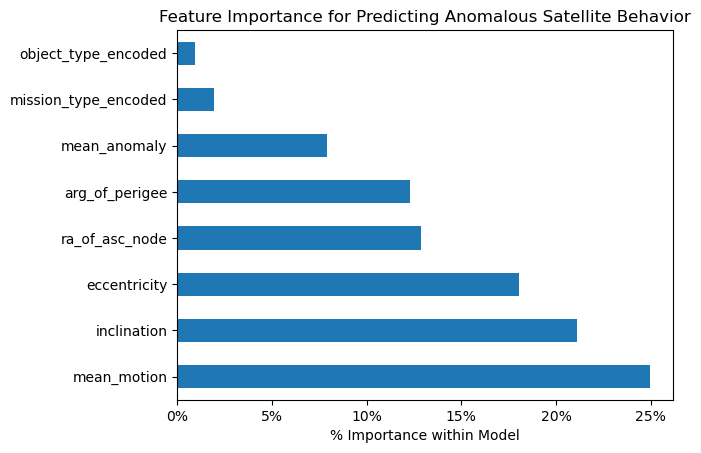

In [28]:
rfc_persat = joblib.load("models/MODEL_rfc_persat.pkl")

importances = pd.Series(rfc_persat.feature_importances_, index=features_to_use).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh')
plt.title('Feature Importance for Predicting Anomalous Satellite Behavior')
plt.xlabel('% Importance within Model'
           )

# Make axis labels into percents
from matplotlib.ticker import PercentFormatter
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.show()

# Step 6: Predict anomalies during the baseline period (12 to 6 months pre-invasion) and the leadup period (6 months pre-invasion), as well as a post-invasion period of one month, with the fitted model. Plot confusion matrices for each period.

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import accuracy_score, confusion_matrix

### Baseline Period (12 - 6mo pre-invasion)

In [30]:
baseline_df = filtered_df[(filtered_df['datetime'] >= "2021-02-24") & (filtered_df['datetime'] < "2021-08-24")]

X_baseline = baseline_df[features_to_use]
y_baseline = baseline_df['outlier_persat']

# Evaluate
y_pred_baseline = rfc_persat.predict(X_baseline)
print(classification_report(y_baseline, y_pred_baseline))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00   1004373
        True       0.88      1.00      0.94     11946

    accuracy                           1.00   1016319
   macro avg       0.94      1.00      0.97   1016319
weighted avg       1.00      1.00      1.00   1016319



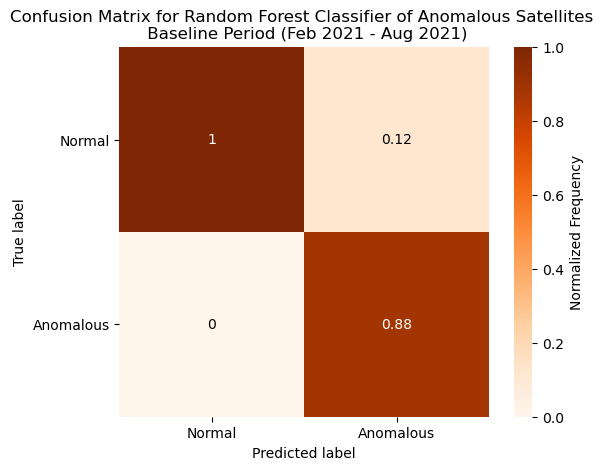

In [31]:
#make and normalize confusion matrix
cm = confusion_matrix(y_baseline, y_pred_baseline)
#print(cm)
total_vals = cm.sum(axis=0)
cm_norm = cm/total_vals
#print(cm/cm.sum(axis=1))

disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Normal", "Anomalous"])
disp.plot()

#match colobar to the solutions
disp.im_.set_cmap("Oranges")
disp.im_.set_clim(0, 1)

#this sets titles
disp.ax_.set_title("Confusion Matrix for Random Forest Classifier of Anomalous Satellites \n Baseline Period (Feb 2021 - Aug 2021)")
cbar = disp.im_.colorbar
cbar.set_label("Normalized Frequency")

#removing the border to match solution plot
for spine in disp.ax_.spines.values():
    spine.set_visible(False)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

#making the text colors fit the color behind them
for ii, text in enumerate(disp.text_.ravel()):
    if ii == 0 or ii == 3:
        text.set_color("white")
    else:
        text.set_color("black")

The above predictions are almost perfect because the 12 to 6mo pre-invasion dataset was used in the training of the model.

### Test Period (6mo leadup to the invasion)

In [32]:
leadup_df = filtered_df[(filtered_df['datetime'] >= "2021-08-24") & (filtered_df['datetime'] < "2022-02-24")]


X_leadup = leadup_df[features_to_use]
y_leadup = leadup_df['outlier_persat']

# Evaluate
y_pred_leadup = rfc_persat.predict(X_leadup)
print(classification_report(y_leadup, y_pred_leadup))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99   1042374
        True       0.84      0.20      0.32     25324

    accuracy                           0.98   1067698
   macro avg       0.91      0.60      0.65   1067698
weighted avg       0.98      0.98      0.97   1067698



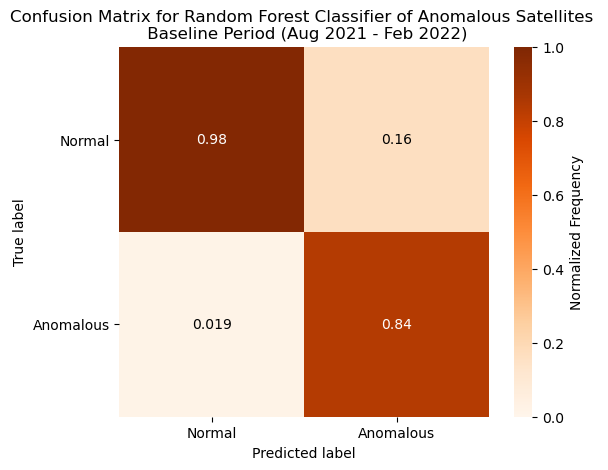

In [46]:
#make and normalize confusion matrix
cm = confusion_matrix(y_leadup, y_pred_leadup)
#print(cm)
total_vals = cm.sum(axis=0)
cm_norm = cm/total_vals
#print(cm/cm.sum(axis=1))

disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Normal", "Anomalous"])
disp.plot()

#match colobar to the solutions
disp.im_.set_cmap("Oranges")
disp.im_.set_clim(0, 1)

#this sets titles
disp.ax_.set_title("Confusion Matrix for Random Forest Classifier of Anomalous Satellites \n Baseline Period (Aug 2021 - Feb 2022)")
cbar = disp.im_.colorbar
cbar.set_label("Normalized Frequency")

#removing the border to match solution plot
for spine in disp.ax_.spines.values():
    spine.set_visible(False)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)
    
#making the text colors fit the color behind them
for ii, text in enumerate(disp.text_.ravel()):
    if ii == 0 or ii == 3:
        text.set_color("white")
    else:
        text.set_color("black")

# Step 7: Plot anomalies for a few individual satellites

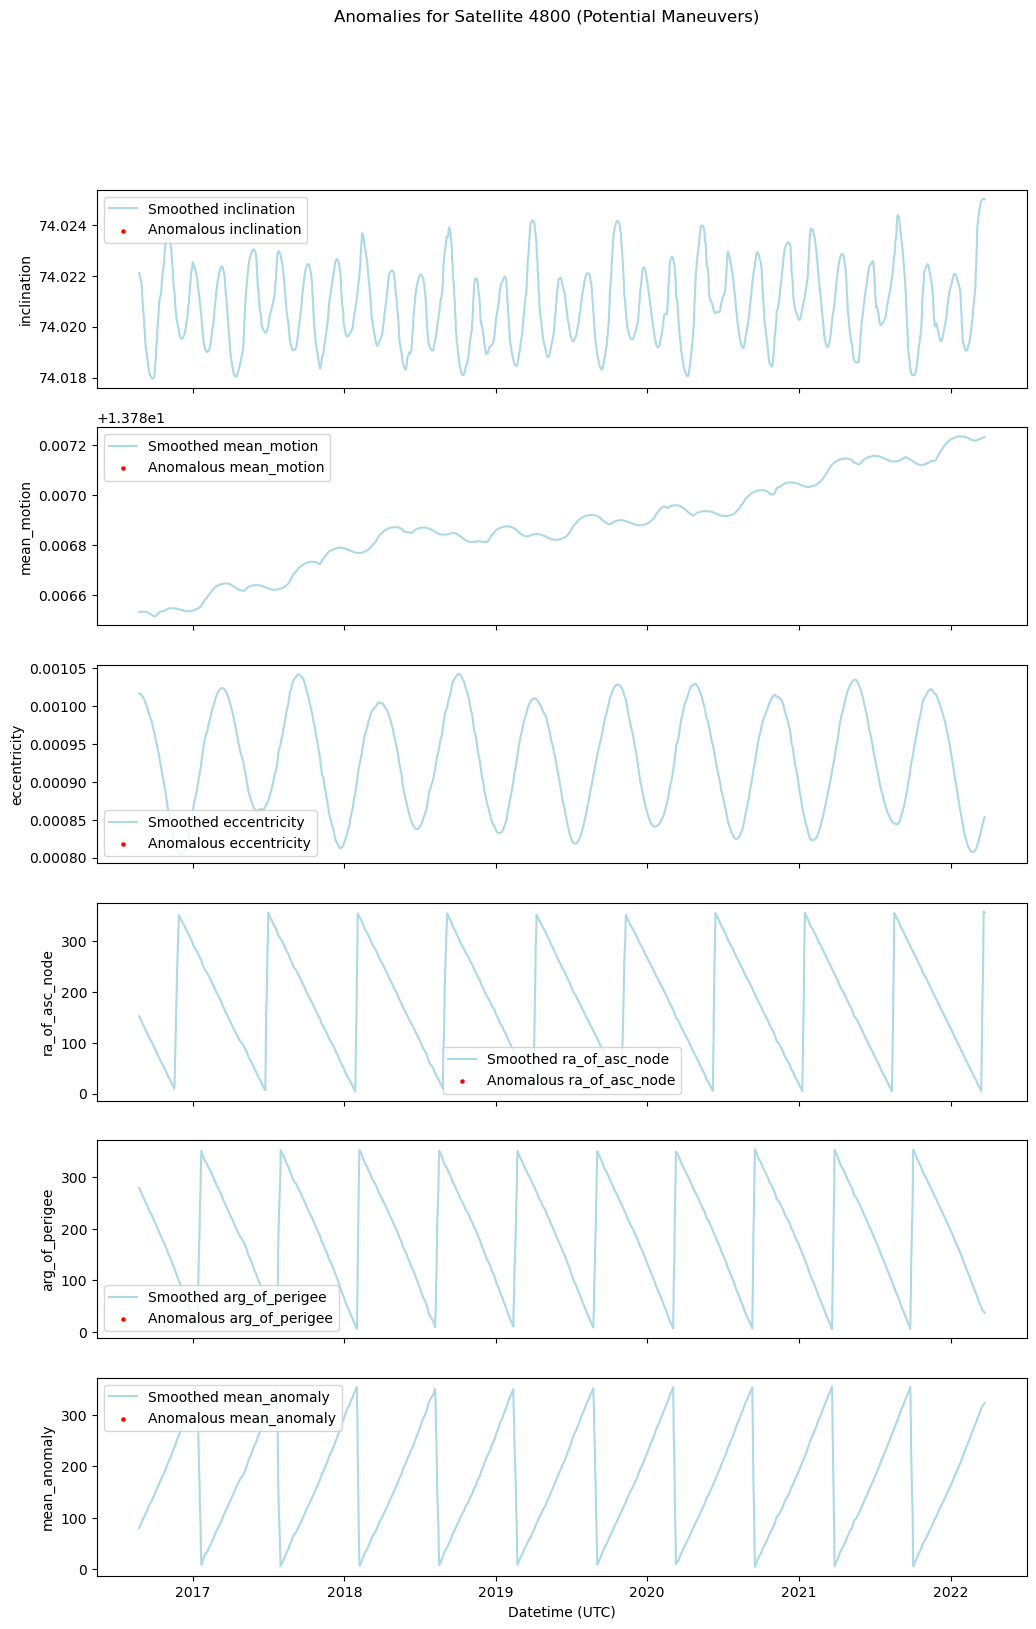

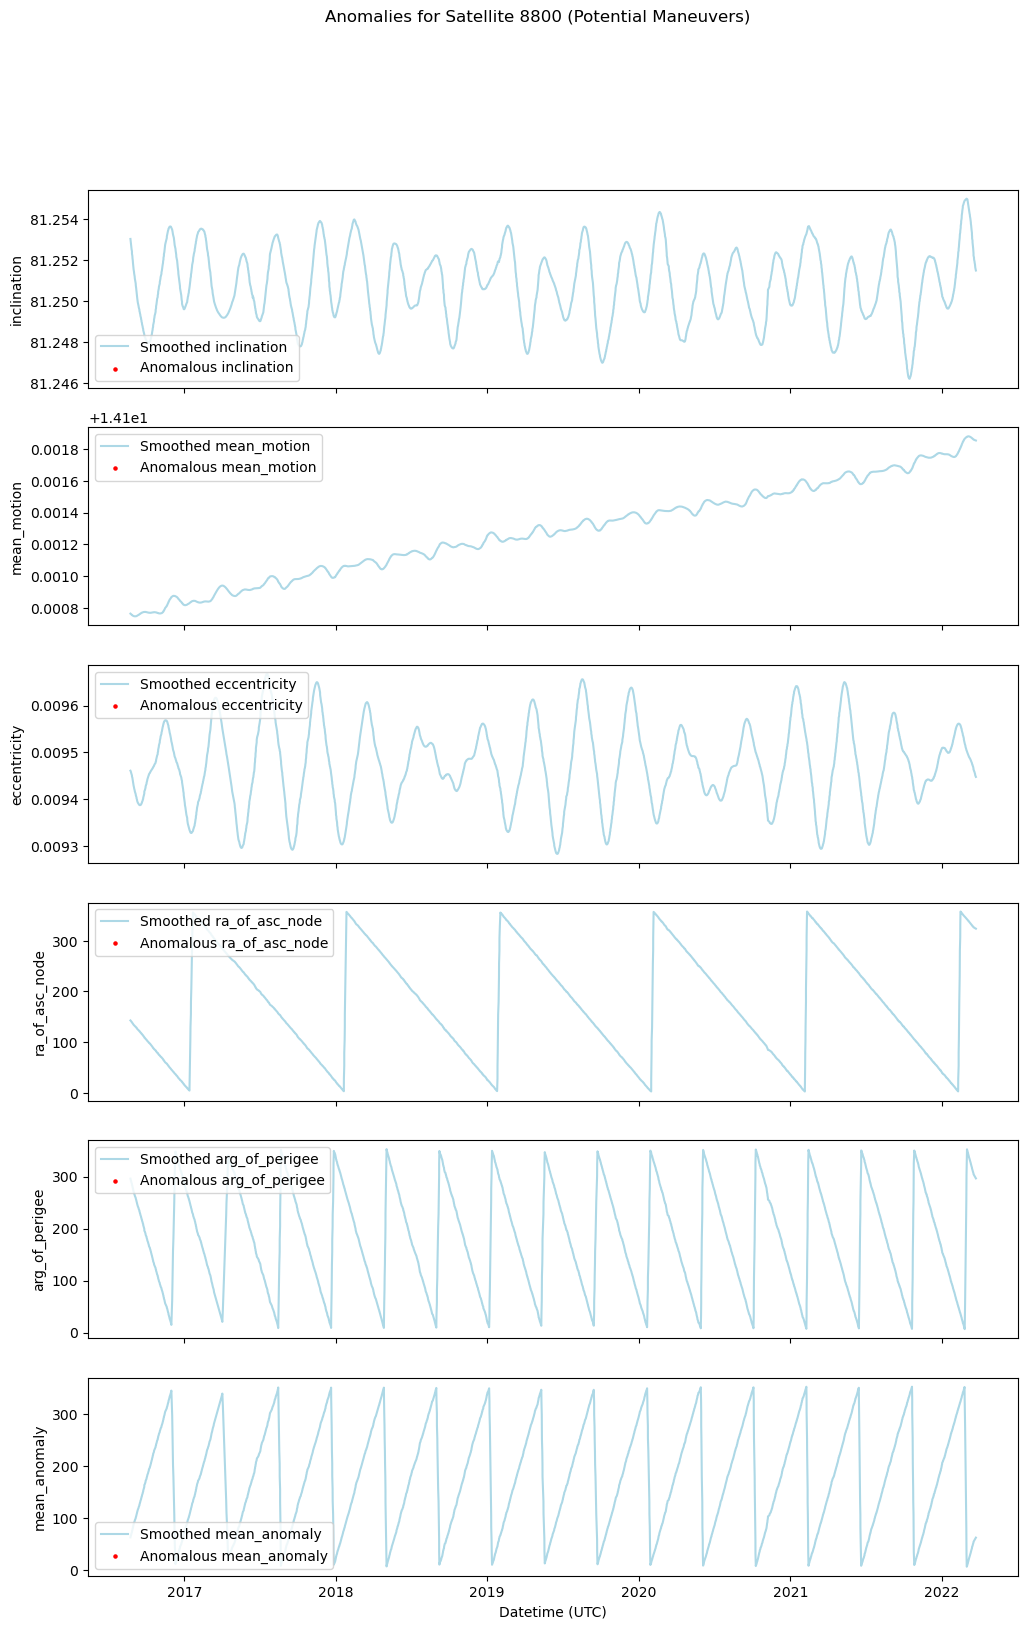

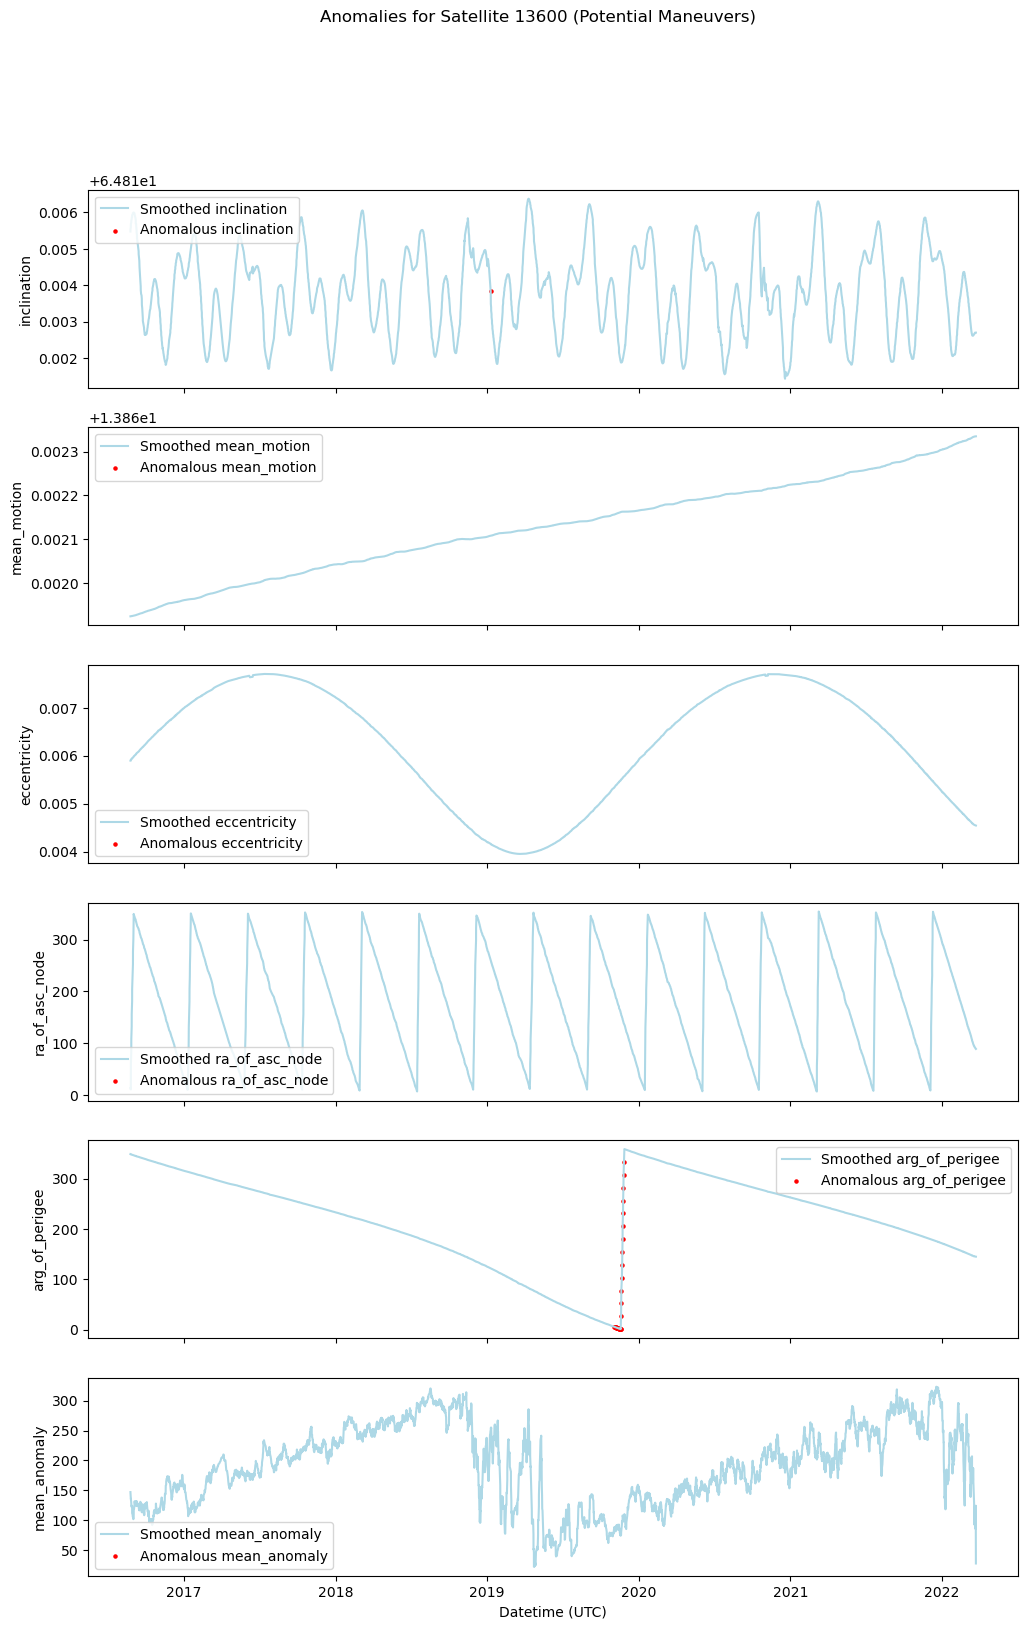

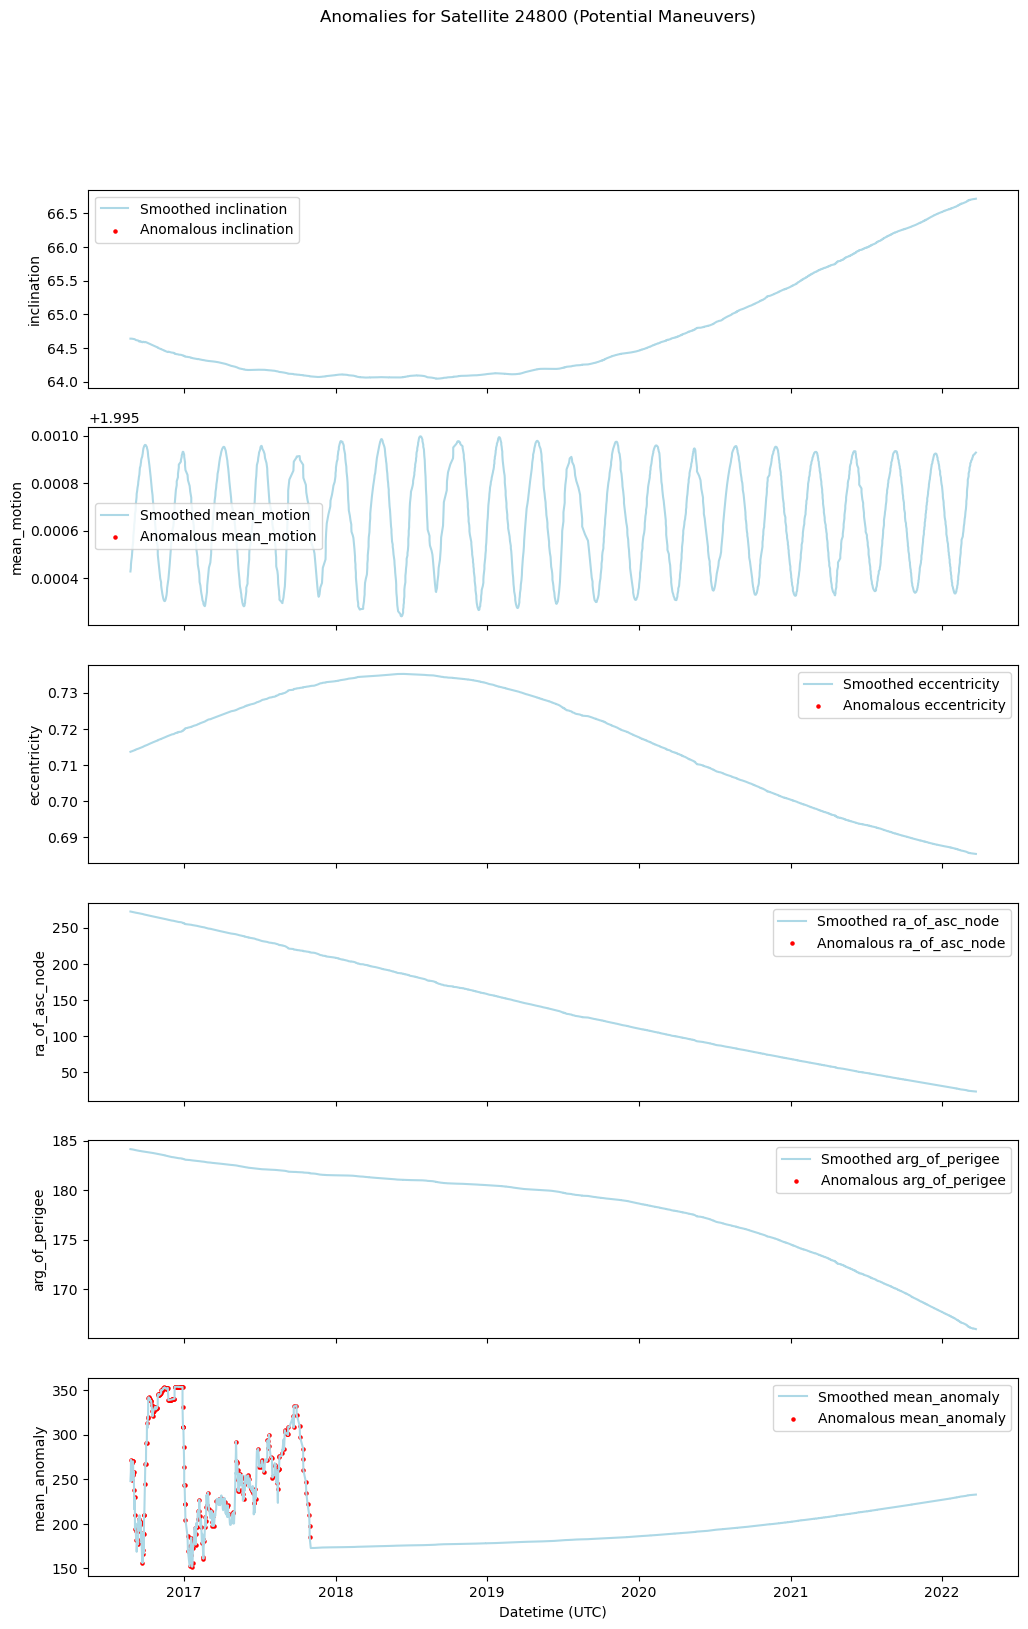

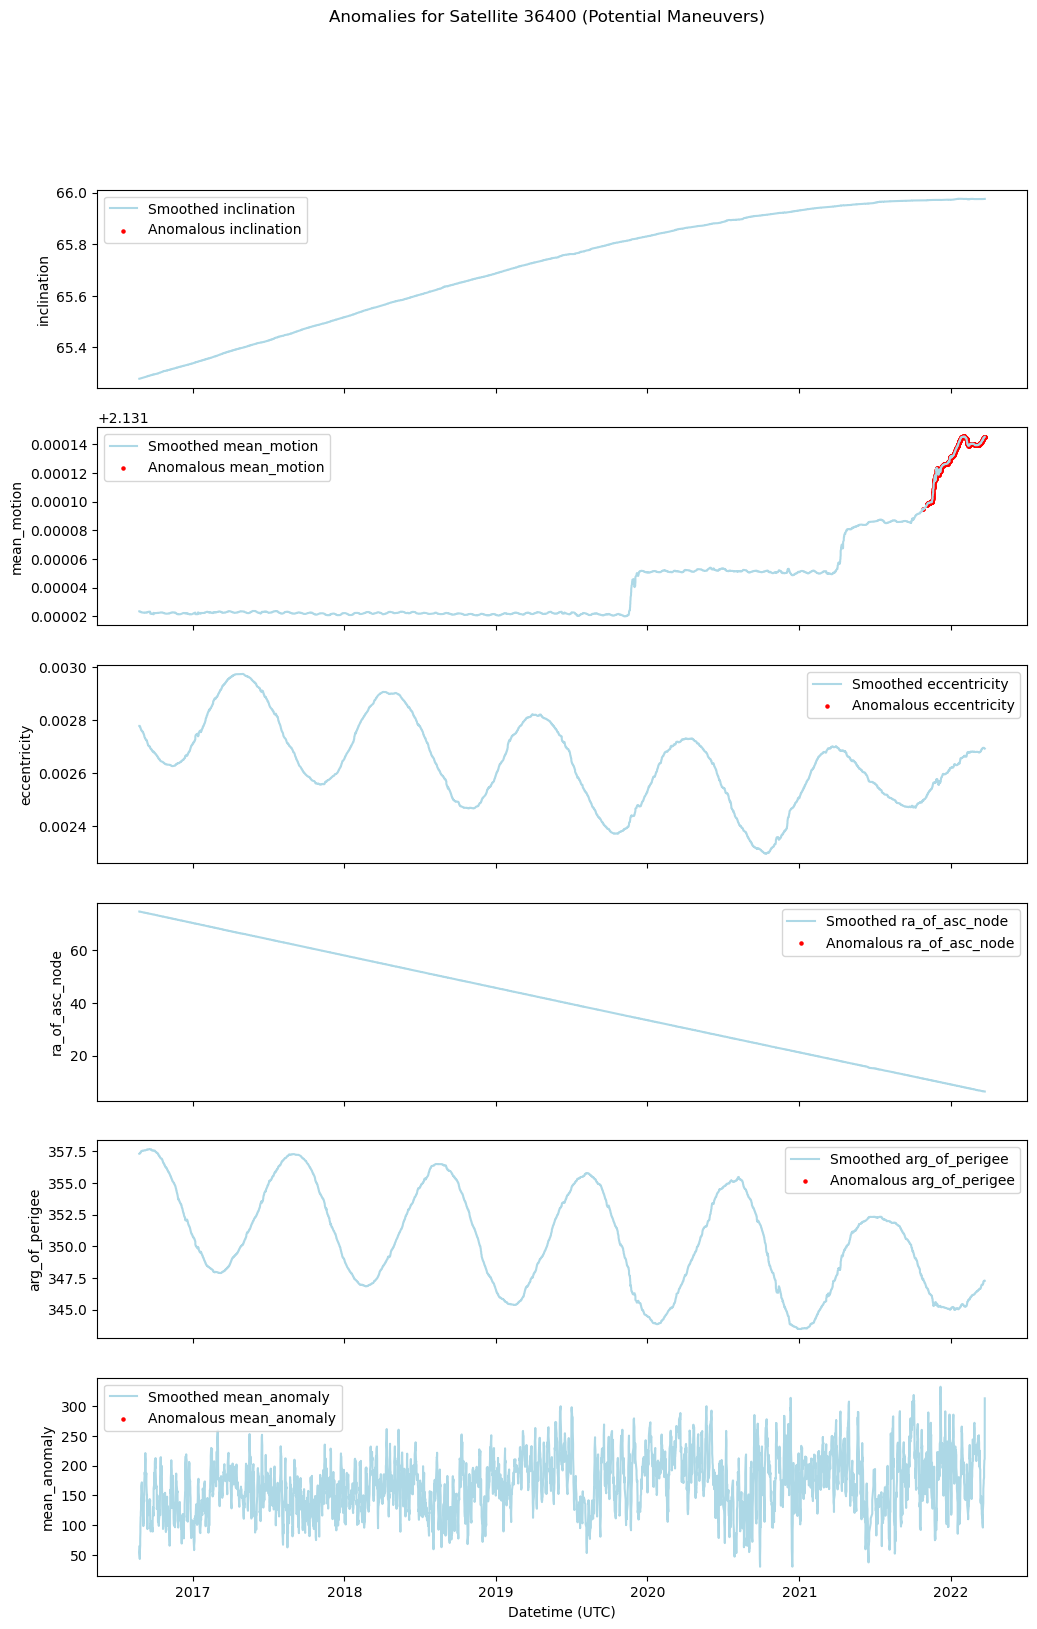

In [41]:
filtered_df['datetime'] = pd.to_datetime(filtered_df['datetime'], errors='coerce')

features = ['inclination', 'mean_motion', 'eccentricity', 
            'ra_of_asc_node', 'arg_of_perigee', 'mean_anomaly']
# redefining to only include orbital elements just in case^

for sat_no, sat_group in filtered_df.groupby('NORAD_CAT_ID'):
    #print(sat_group.head())

    if sat_no % 400 == 0:

        fig, axes = plt.subplots(len(features), 1, figsize=(12, 18), sharex=True)
        fig.suptitle(f"Anomalies for Satellite {sat_no} (Potential Maneuvers)")

        for idx, feature in enumerate(features):

            if feature in sat_group.columns:
                sat_group[f'{feature}_smoothed'] = (
                    sat_group[feature]
                    .rolling(window=14, min_periods=1)
                    .mean()
                    .fillna(0)
                )
            axes[idx].plot(sat_group[sat_group[f'{feature}_smoothed'].notna()]['datetime'],
                           sat_group[sat_group[f'{feature}_smoothed'].notna()][f'{feature}_smoothed'],
                           label=f'Smoothed {feature}', color='lightblue')

            
            anomaly_points = sat_group[sat_group[f'outlier_{feature}'] == True]['datetime']
            anomaly_values = sat_group[sat_group[f'outlier_{feature}'] == True][f'{feature}_smoothed']
            
            axes[idx].scatter(anomaly_points, anomaly_values, color='red',
                            label=f'Anomalous {feature}', s=5)
            
            axes[idx].set_ylabel(f'{feature}')
            axes[idx].legend()
        plt.xlabel('Datetime (UTC)')
        plt.show()

# Step 8: Plot total anomalies by month, then by month and discipline

In [37]:
import plotly.graph_objs as go


# Extract month for grouping
filtered_df['month'] = filtered_df['datetime'].dt.to_period('M')

# Filter the DataFrame for rows where the anomaly is True
anomalies = filtered_df[filtered_df['outlier_persat'] == True].copy()
anomalies = anomalies[anomalies['datetime'] > "2018-01-01"]
print(len(anomalies))

# Group anomalies by month and count occurrences
monthly_anomaly_counts = anomalies.groupby('month').size().reset_index(name='count')

# Convert the period index to datetime for plotting
monthly_anomaly_counts['month'] = monthly_anomaly_counts['month'].dt.to_timestamp()

# Interactive Plotly figure
fig = go.Figure()

# Trace for overall anomalies by month
fig.add_trace(go.Scatter(
    x=monthly_anomaly_counts['month'],
    y=monthly_anomaly_counts['count'],
    mode='lines+markers',
    name='Overall Anomalies'
))

# Plot layout
fig.update_layout(
    title="Count of Satellite Anomalies by Month",
    xaxis=dict(
        title="Month",
        showgrid=True,
        rangeslider=dict(visible=True),  # Add a range slider for zooming
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(step="all")
            ]
        )
    ),
    yaxis=dict(
        title="Count of Anomalies",
        showgrid=True
    ),
    legend_title="Anomalies",
    template="plotly_white",
    hovermode="x unified"
)

# Show the plot
fig.show()

84482


In [38]:
import plotly.graph_objs as go
import plotly.express as px


# Extract month for grouping
filtered_df['month'] = filtered_df['datetime'].dt.to_period('M')

# Filter the DataFrame for rows where the anomaly is True
anomalies = filtered_df[filtered_df['outlier_persat'] == True].copy()
anomalies = anomalies[anomalies['datetime'] > "2018-01-01"]
print(f"Total anomalies: {len(anomalies)}")

# Group anomalies by month and Discipline, then count occurrences
monthly_anomaly_counts = (
    anomalies.groupby(['month', 'Discipline'])
    .size()
    .reset_index(name='count')
)

# Convert period index to datetime for plotting
monthly_anomaly_counts['month'] = monthly_anomaly_counts['month'].dt.to_timestamp()

# Interactive Plotly figure
fig = go.Figure()
color_sequence = px.colors.qualitative.Light24  # Dark24 has 24 colors

# Add a separate line for each Discipline
for i, discipline in enumerate(monthly_anomaly_counts['Discipline'].unique()):
    df_subset = monthly_anomaly_counts[monthly_anomaly_counts['Discipline'] == discipline]
    fig.add_trace(go.Scatter(
        x=df_subset['month'],
        y=df_subset['count'],
        mode='lines+markers',
        name=str(discipline),
        line=dict(color=color_sequence[i])
    ))

# Plot layout
fig.update_layout(
    title="Count of Satellite Anomalies by Month and Discipline",
    xaxis=dict(
        title="Month",
        showgrid=True,
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(step="all")
            ]
        )
    ),
    yaxis=dict(
        title="Count of Anomalies",
        showgrid=True
    ),
    legend_title="Discipline",
    template="plotly_white",
    hovermode="x unified"
)

# Show the plot
fig.show()


Total anomalies: 84482


# Step 9: Plot anomalies by month for each orbital element

In [39]:
def calculate_rate_of_change(df, feature, time_column='datetime', min_dt=0.01):
    df = df.sort_values(time_column)
    
    delta_feature = df[feature].diff()
    delta_time = df[time_column].diff().dt.total_seconds()# / (3600 * 24)  # in days
    #print(feature, delta_time)

    # Handle invalid or too-small time steps
    delta_time = delta_time.mask((delta_time.abs() <= min_dt) | (delta_time.isna()), np.nan)
    
    rate = delta_feature / delta_time
    
    return rate

for feature in features:
    filtered_df[f'{feature}_changes'] = calculate_rate_of_change(filtered_df, feature)

c:\Users\kylyn\anaconda3\envs\a3560\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

c:\Users\kylyn\anaconda3\envs\a3560\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

c:\Users\kylyn\anaconda3\envs\a3560\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

c:\Users\kylyn\anaconda3\envs\a3560\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

c:\Users\kylyn\anaconda3\envs\a3560\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10



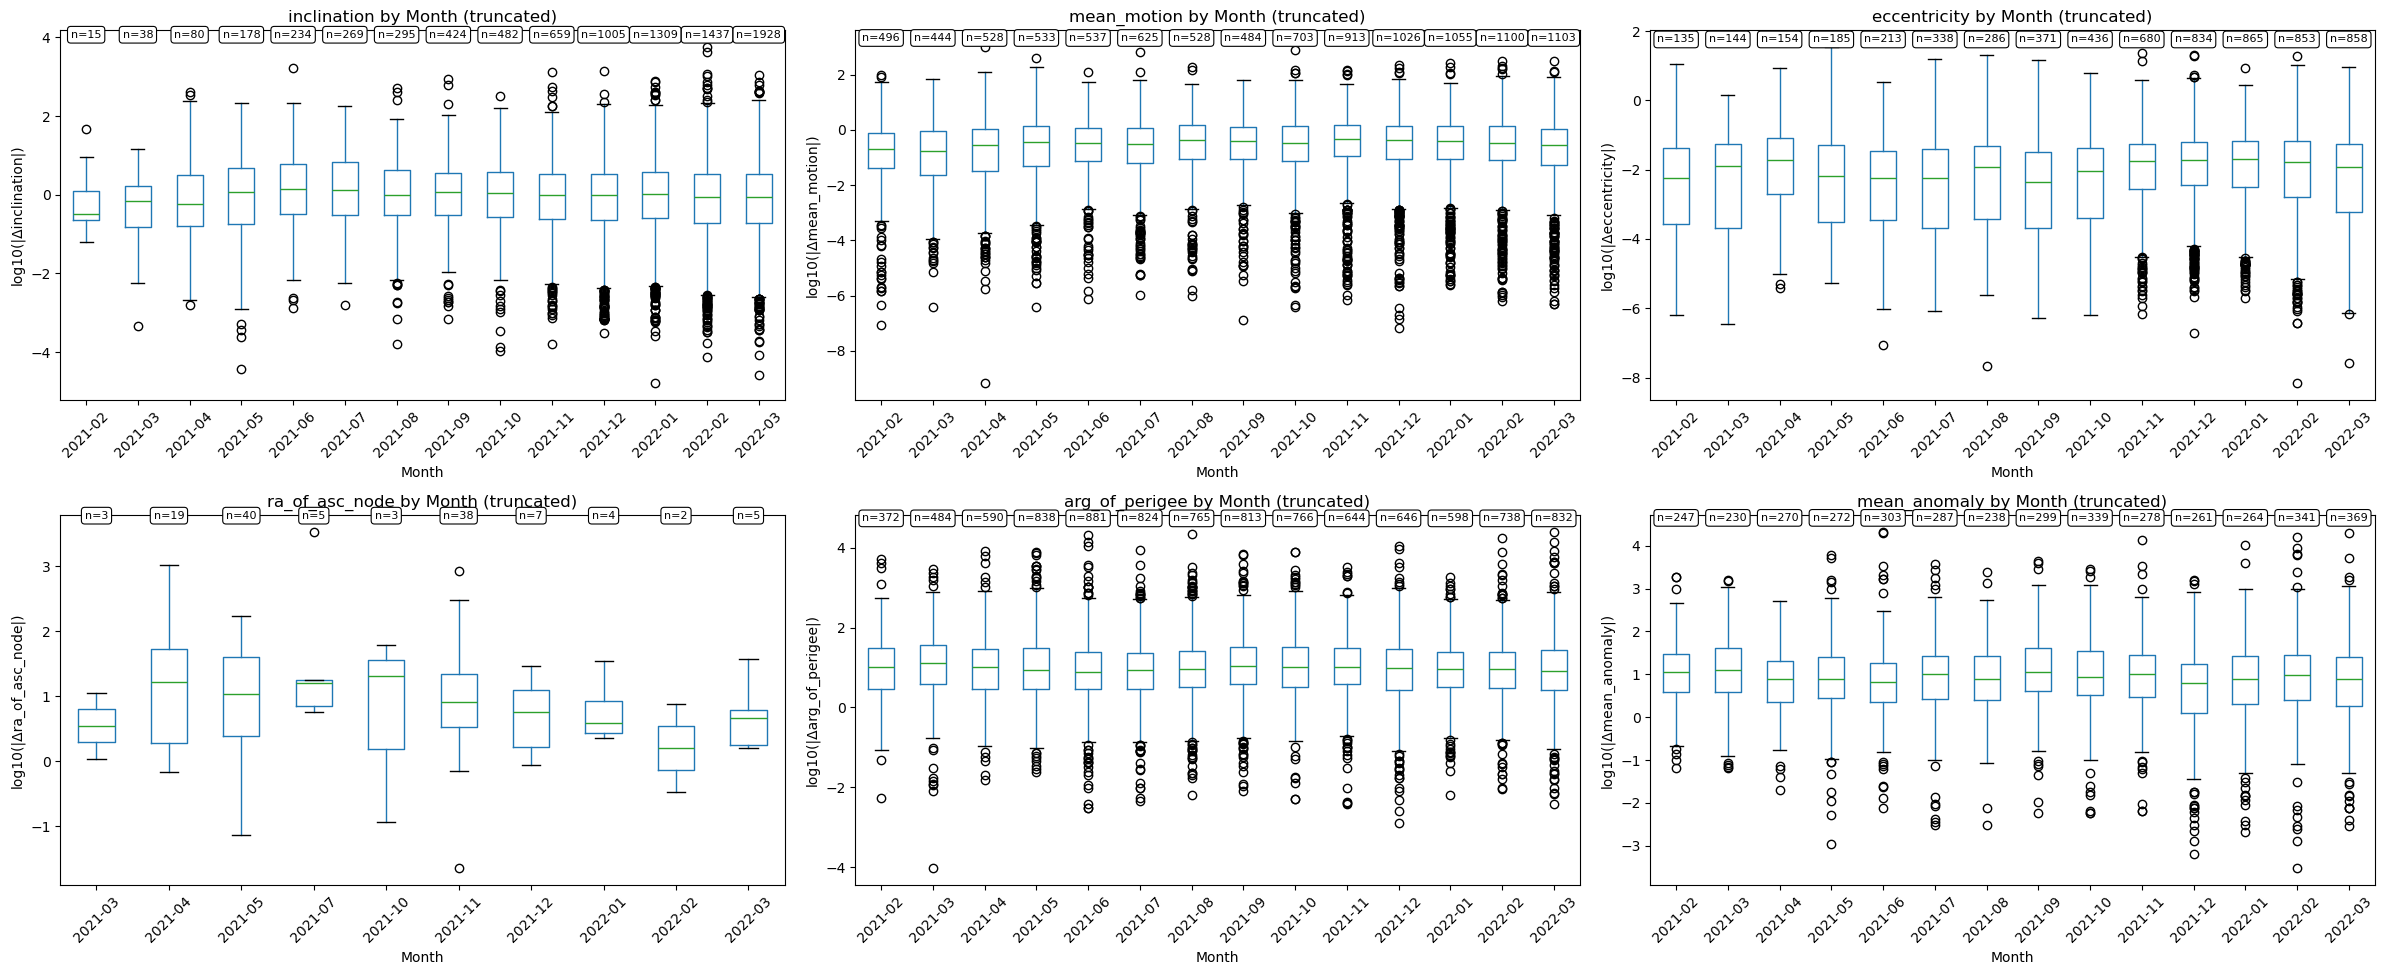

In [53]:
feature_changes = [
    'inclination_changes',
    'mean_motion_changes',
    'eccentricity_changes',
    'ra_of_asc_node_changes',
    'arg_of_perigee_changes',
    'mean_anomaly_changes'
]

features = ['inclination',
            'mean_motion',
            'eccentricity', 
            'ra_of_asc_node',
            'arg_of_perigee',
            'mean_anomaly'
]


clipped_df = filtered_df.copy()
clipped_df = clipped_df[clipped_df['datetime'] > "2021-02-01"].copy()
clipped_df = clipped_df[clipped_df['outlier_persat'] == True].copy()

# Ensure month column exists and is a string (e.g. "2021-03")
clipped_df['month'] = clipped_df['datetime'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(2, 3, figsize=(24, 10))
axes = axes.flatten()

for ii, feature_change in enumerate(feature_changes):
    # Filter to numeric and drop NaNs
    outlier_df = clipped_df[[feature_change, features[ii], 'month', f'outlier_{features[ii]}']].dropna()
    outlier_df = outlier_df[outlier_df[f'outlier_{features[ii]}'] == True]
    # this uses the definition of features from before, NOT changes

    outlier_df['clipped_feature'] = np.log10(outlier_df[feature_change].abs())

    # Compute count per month
    month_counts = outlier_df.groupby('month').size()

    # Create the boxplot
    outlier_df.boxplot(column='clipped_feature', by='month', grid=False, ax=axes[ii])

    # Annotate counts above each month box
    for j, month in enumerate(month_counts.index):
        count = month_counts[month]
        # Get y-position slightly above the top whisker
        y_pos = outlier_df['clipped_feature'].max() * 1.05
        axes[ii].text(j + 1, y_pos, "n="+str(count),
                      ha='center', va='bottom',
                      fontsize=8, rotation=0,
                      bbox=dict(
                        boxstyle="round,pad=0.3",
                        edgecolor="black",
                        facecolor="white",
                        linewidth=0.8
                    ))

    axes[ii].set_title(f'{features[ii]} by Month (truncated)')
    axes[ii].set_xlabel('Month')
    axes[ii].set_ylabel('log10(|Δ' + feature_change.split('_changes')[0] + '|)')
    #axes[ii].set_yscale('log')
    axes[ii].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()
